In [1]:
# Phase 10 – Shock Simulation Engine | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pickle
import sys

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase10"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P8 = PROJECT / "outputs" / "phase8" / "data"
P9 = PROJECT / "outputs" / "phase9"

print("=" * 60)
print("Phase 10 – Shock Simulation Engine | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

# Phase-9 winner
winner_path = P9 / "tables" / "phase9_winner.csv"
if winner_path.exists():
    winner = pd.read_csv(winner_path).iloc[0].to_dict()
    print(f"Phase-9 winner: {winner.get('algorithm')} | {winner.get('level')} | R={winner.get('mean_reward')}")
else:
    winner = {"algorithm": "PPO", "level": "moderate"}
    print("Winner file missing → default PPO moderate")

print(f"base_features : {base_features.shape}")
print(f"emb_GraphSAGE : {emb.shape}")
print(f"nodes         : {len(nodes)}")
print(f"years         : {panel['year'].min()}–{panel['year'].max()}")

print("\nCell 1 completed successfully.")

Phase 10 – Shock Simulation Engine | Cell 1
Timestamp : 2026-09-30 08:39:37
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase10
Phase-9 winner: PPO | moderate | R=33.626648665327046
base_features : (378, 16)
emb_GraphSAGE : (378, 32)
nodes         : 18
years         : 2000–2020

Cell 1 completed successfully.


In [2]:
# Phase 10 – Shock Simulation Engine | Cell 2: Shock catalog + apply

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
OUT_DATA = PROJECT / "outputs" / "phase10" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase10" / "tables"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 10 – Cell 2: Shock catalog")
print("=" * 60)

# Severity multipliers
SEVERITY = {
    "Mild": 0.25,
    "Moderate": 0.50,
    "Severe": 0.75,
    "Extreme": 1.00,
}

# Shock type → effect on SR and feature proxy (direction + base magnitude)
# Negative SR impact = crisis damage; feature_shift applied to current_features mean directionally
SHOCK_TYPES = {
    "Recession": {
        "sr_impact": -0.25,      # drop structural resilience
        "feature_shift": -0.15,  # macro/network stress
        "description": "Output/trade contraction",
    },
    "Inflation": {
        "sr_impact": -0.15,
        "feature_shift": 0.10,   # price/pressure up
        "description": "Price level surge",
    },
    "BankingCrisis": {
        "sr_impact": -0.30,
        "feature_shift": -0.20,
        "description": "Credit/intermediation freeze",
    },
    "DebtCrisis": {
        "sr_impact": -0.22,
        "feature_shift": -0.12,
        "description": "Sovereign/private debt stress",
    },
}

def apply_shock(env, shock_type, severity, rng=None):
    """Apply one-shot shock to current env state (in-place)."""
    if rng is None:
        rng = np.random.default_rng(0)
    sev = SEVERITY[severity]
    spec = SHOCK_TYPES[shock_type]
    # SR hit with small noise
    delta_sr = spec["sr_impact"] * sev + rng.normal(0, 0.01 * sev)
    env.current_sr = np.clip(env.current_sr + delta_sr, 0.0, 1.5)
    # feature shift
    delta_f = spec["feature_shift"] * sev
    env.current_features = env.current_features + delta_f + rng.normal(0, 0.01 * sev, size=env.current_features.shape)
    return {
        "shock_type": shock_type,
        "severity": severity,
        "delta_sr": float(delta_sr),
        "delta_feature": float(delta_f),
        "sr_after": float(np.mean(env.current_sr)),
    }

# Build full scenario grid
scenarios = []
for st in SHOCK_TYPES:
    for sev in SEVERITY:
        scenarios.append({
            "shock_type": st,
            "severity": sev,
            "severity_mult": SEVERITY[sev],
            "sr_impact_base": SHOCK_TYPES[st]["sr_impact"],
            "feature_shift_base": SHOCK_TYPES[st]["feature_shift"],
            "description": SHOCK_TYPES[st]["description"],
        })
scen_df = pd.DataFrame(scenarios)
scen_df.to_csv(OUT_TAB / "shock_scenario_catalog.csv", index=False)
print(f"Scenarios defined: {len(scen_df)}")
print(scen_df.head(8).to_string(index=False))

# Smoke: apply each type at Moderate on a fresh env
base = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

env = EconomicsNetworkEnv(base, emb, sr, panel, nodes, level="moderate", seed=0)
obs, _ = env.reset(seed=0)
sr_before = float(np.mean(env.current_sr))
print(f"\nSR before shocks: {sr_before:.4f}")
for st in SHOCK_TYPES:
    env2 = EconomicsNetworkEnv(base, emb, sr, panel, nodes, level="moderate", seed=0)
    env2.reset(seed=0)
    info = apply_shock(env2, st, "Moderate", rng=np.random.default_rng(1))
    print(f"  {st:15s} | dSR={info['delta_sr']:+.4f} | SR_after={info['sr_after']:.4f}")

# Persist helpers
payload = {
    "severity": SEVERITY,
    "shock_types": SHOCK_TYPES,
    "n_scenarios": len(scen_df),
}
with open(OUT_DATA / "shock_engine_spec.pkl", "wb") as f:
    pickle.dump(payload, f)
print(f"\nSaved → {OUT_DATA / 'shock_engine_spec.pkl'}")
print("\nCell 2 completed successfully.")

Phase 10 – Cell 2: Shock catalog
Scenarios defined: 16
shock_type severity  severity_mult  sr_impact_base  feature_shift_base              description
 Recession     Mild           0.25           -0.25               -0.15 Output/trade contraction
 Recession Moderate           0.50           -0.25               -0.15 Output/trade contraction
 Recession   Severe           0.75           -0.25               -0.15 Output/trade contraction
 Recession  Extreme           1.00           -0.25               -0.15 Output/trade contraction
 Inflation     Mild           0.25           -0.15                0.10        Price level surge
 Inflation Moderate           0.50           -0.15                0.10        Price level surge
 Inflation   Severe           0.75           -0.15                0.10        Price level surge
 Inflation  Extreme           1.00           -0.15                0.10        Price level surge

SR before shocks: 0.3258
  Recession       | dSR=-0.1233 | SR_after=0.2025
  Inf

In [3]:
# Phase 10 – Cell 3: Evaluate Phase-9 winner under all shocks

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import pickle
from stable_baselines3 import PPO

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
P9 = PROJECT / "outputs" / "phase9"
OUT_TAB = PROJECT / "outputs" / "phase10" / "tables"
OUT_DATA = PROJECT / "outputs" / "phase10" / "data"
OUT_FIG = PROJECT / "outputs" / "phase10" / "figures"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 10 – Cell 3: Winner under shocks")
print("=" * 60)

base = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

with open(OUT_DATA / "shock_engine_spec.pkl", "rb") as f:
    spec = pickle.load(f)
SEVERITY = spec["severity"]
SHOCK_TYPES = spec["shock_types"]

# Load Phase-9 winner model (PPO moderate)
model_path = P9 / "models" / "PPO_moderate_gs.zip"
model = PPO.load(str(model_path))
print(f"Loaded model: {model_path.name}")

def apply_shock(env, shock_type, severity, rng):
    sev = SEVERITY[severity]
    sdef = SHOCK_TYPES[shock_type]
    delta_sr = sdef["sr_impact"] * sev + rng.normal(0, 0.01 * sev)
    env.current_sr = np.clip(env.current_sr + delta_sr, 0.0, 1.5)
    delta_f = sdef["feature_shift"] * sev
    env.current_features = env.current_features + delta_f + rng.normal(0, 0.01 * sev, size=env.current_features.shape)
    return float(delta_sr)

def run_episode(shock_type=None, severity=None, n_ep=15, seed=0):
    rewards, sr_end, sr_imp = [], [], []
    for ep in range(n_ep):
        env = EconomicsNetworkEnv(base, emb, sr, panel, nodes, level="moderate", seed=seed + ep)
        obs, _ = env.reset(seed=seed + ep)
        rng = np.random.default_rng(seed + 1000 + ep)
        if shock_type is not None:
            apply_shock(env, shock_type, severity, rng)
            obs = env._get_obs()  # refresh obs after shock
        done, tot, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            tot += r
            done = term or trunc
        rewards.append(tot)
        sr_end.append(info.get("sr_mean", np.nan))
        sr_imp.append(info.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_sr_end": float(np.nanmean(sr_end)),
        "mean_sr_improve": float(np.nanmean(sr_imp)),
    }

rows = []
# baseline no shock
base_stats = run_episode(None, None)
rows.append({"shock_type": "None", "severity": "None", **base_stats})
print(f"Baseline (no shock) | R={base_stats['mean_reward']:.3f} | dSR={base_stats['mean_sr_improve']:.3f}")

for st in SHOCK_TYPES:
    for sev in SEVERITY:
        stt = run_episode(st, sev)
        rows.append({"shock_type": st, "severity": sev, **stt})
        print(f"{st:15s} | {sev:8s} | R={stt['mean_reward']:.3f} | dSR={stt['mean_sr_improve']:.3f}")

res = pd.DataFrame(rows)
res.to_csv(OUT_TAB / "ppo_moderate_under_shocks.csv", index=False)

# impact vs baseline
res["reward_gap"] = res["mean_reward"] - base_stats["mean_reward"]
res["sr_gap"] = res["mean_sr_improve"] - base_stats["mean_sr_improve"]
res.to_csv(OUT_TAB / "ppo_moderate_shock_impact.csv", index=False)

print("\n--- Worst shocks by reward ---")
print(res[res.shock_type != "None"].sort_values("mean_reward").head(5).to_string(index=False))
print(f"\nSaved → {OUT_TAB / 'ppo_moderate_under_shocks.csv'}")
print("\nCell 3 completed successfully.")

Phase 10 – Cell 3: Winner under shocks
Loaded model: PPO_moderate_gs.zip
Baseline (no shock) | R=33.896 | dSR=1.162
Recession       | Mild     | R=31.931 | dSR=1.161
Recession       | Moderate | R=29.807 | dSR=1.161
Recession       | Severe   | R=27.720 | dSR=1.161
Recession       | Extreme  | R=26.165 | dSR=1.161
Inflation       | Mild     | R=32.738 | dSR=1.160
Inflation       | Moderate | R=31.432 | dSR=1.160
Inflation       | Severe   | R=30.026 | dSR=1.159
Inflation       | Extreme  | R=28.524 | dSR=1.158
BankingCrisis   | Mild     | R=31.516 | dSR=1.161
BankingCrisis   | Moderate | R=28.951 | dSR=1.161
BankingCrisis   | Severe   | R=26.717 | dSR=1.161
BankingCrisis   | Extreme  | R=25.319 | dSR=1.161
DebtCrisis      | Mild     | R=32.179 | dSR=1.160
DebtCrisis      | Moderate | R=30.323 | dSR=1.161
DebtCrisis      | Severe   | R=28.439 | dSR=1.161
DebtCrisis      | Extreme  | R=26.846 | dSR=1.161

--- Worst shocks by reward ---
   shock_type severity  mean_reward  std_reward  mea

In [4]:
# Phase 10 – Cell 3B: Evaluate TGN-based PPO under same shocks

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import pickle
from stable_baselines3 import PPO

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
P9_TGN = PROJECT / "outputs" / "phase9_tgn" / "models"
OUT_TAB = PROJECT / "outputs" / "phase10" / "tables"
OUT_DATA = PROJECT / "outputs" / "phase10" / "data"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 10 – Cell 3B: TGN-PPO under shocks (comparison)")
print("=" * 60)

# State for TGN run must use TGN embedding
base = np.load(P8 / "base_features.npy")
emb_tgn_path = P8 / "emb_TGN.npy"
if not emb_tgn_path.exists():
    emb_tgn_path = PROJECT / "outputs" / "phase7" / "data" / "emb_TGN_stable.npy"
emb_tgn = np.load(emb_tgn_path)
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

with open(OUT_DATA / "shock_engine_spec.pkl", "rb") as f:
    spec = pickle.load(f)
SEVERITY = spec["severity"]
SHOCK_TYPES = spec["shock_types"]

print(f"TGN embedding: {emb_tgn.shape} from {emb_tgn_path}")
print(f"TGN model dir: {P9_TGN}")

def apply_shock(env, shock_type, severity, rng):
    sev = SEVERITY[severity]
    sdef = SHOCK_TYPES[shock_type]
    delta_sr = sdef["sr_impact"] * sev + rng.normal(0, 0.01 * sev)
    env.current_sr = np.clip(env.current_sr + delta_sr, 0.0, 1.5)
    delta_f = sdef["feature_shift"] * sev
    env.current_features = env.current_features + delta_f + rng.normal(
        0, 0.01 * sev, size=env.current_features.shape
    )
    return float(delta_sr)

def run_episode(model, emb, level, shock_type=None, severity=None, n_ep=15, seed=0):
    rewards, sr_imp = [], []
    for ep in range(n_ep):
        env = EconomicsNetworkEnv(base, emb, sr, panel, nodes, level=level, seed=seed + ep)
        obs, _ = env.reset(seed=seed + ep)
        rng = np.random.default_rng(seed + 1000 + ep)
        if shock_type is not None:
            apply_shock(env, shock_type, severity, rng)
            obs = env._get_obs()
        done, tot, info = False, 0.0, {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            tot += r
            done = term or trunc
        rewards.append(tot)
        sr_imp.append(info.get("sr_improve", np.nan))
    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "mean_sr_improve": float(np.nanmean(sr_imp)),
    }

# Evaluate TGN PPO for each saved level under full shock grid
tgn_models = {
    "normal": P9_TGN / "PPO_normal.zip",
    "moderate": P9_TGN / "PPO_moderate.zip",
    "strict": P9_TGN / "PPO_strict.zip",
}

rows = []
for level, path in tgn_models.items():
    if not path.exists():
        print(f"Missing: {path}")
        continue
    model = PPO.load(str(path))
    print(f"\n=== TGN-PPO | level={level} | {path.name} ===")
    # baseline
    st = run_episode(model, emb_tgn, level, None, None)
    rows.append({"embedding": "TGN", "policy_level": level,
                 "shock_type": "None", "severity": "None", **st})
    print(f"  Baseline | R={st['mean_reward']:.3f} | dSR={st['mean_sr_improve']:.3f}")
    for s_type in SHOCK_TYPES:
        for sev in SEVERITY:
            st = run_episode(model, emb_tgn, level, s_type, sev)
            rows.append({"embedding": "TGN", "policy_level": level,
                         "shock_type": s_type, "severity": sev, **st})
            print(f"  {s_type:15s} | {sev:8s} | R={st['mean_reward']:.3f} | dSR={st['mean_sr_improve']:.3f}")

tgn_df = pd.DataFrame(rows)
tgn_df.to_csv(OUT_TAB / "ppo_tgn_under_shocks.csv", index=False)

# Compare GraphSAGE moderate PPO vs TGN moderate PPO (if both exist)
gs_path = OUT_TAB / "ppo_moderate_under_shocks.csv"
if gs_path.exists() and len(tgn_df):
    gs = pd.read_csv(gs_path)
    gs["embedding"] = "GraphSAGE"
    gs["policy_level"] = "moderate"
    tgn_mod = tgn_df[tgn_df["policy_level"] == "moderate"].copy()
    # align on shock_type, severity
    cmp = gs.merge(
        tgn_mod,
        on=["shock_type", "severity"],
        suffixes=("_gs", "_tgn"),
        how="inner",
    )
    cmp["reward_diff_gs_minus_tgn"] = cmp["mean_reward_gs"] - cmp["mean_reward_tgn"]
    cmp.to_csv(OUT_TAB / "ppo_gs_vs_tgn_under_shocks.csv", index=False)
    print("\n--- GraphSAGE moderate vs TGN moderate (reward) ---")
    cols = ["shock_type", "severity", "mean_reward_gs", "mean_reward_tgn", "reward_diff_gs_minus_tgn"]
    print(cmp[cols].to_string(index=False))

print(f"\nSaved → {OUT_TAB / 'ppo_tgn_under_shocks.csv'}")
print("\nCell 3B completed successfully.")

Phase 10 – Cell 3B: TGN-PPO under shocks (comparison)
TGN embedding: (378, 32) from D:\univercity\omid_project\economics_project\outputs\phase8\data\emb_TGN.npy
TGN model dir: D:\univercity\omid_project\economics_project\outputs\phase9_tgn\models

=== TGN-PPO | level=normal | PPO_normal.zip ===
  Baseline | R=33.230 | dSR=1.164
  Recession       | Mild     | R=31.903 | dSR=1.164
  Recession       | Moderate | R=30.514 | dSR=1.164
  Recession       | Severe   | R=29.140 | dSR=1.164
  Recession       | Extreme  | R=28.083 | dSR=1.164
  Inflation       | Mild     | R=32.462 | dSR=1.164
  Inflation       | Moderate | R=31.656 | dSR=1.164
  Inflation       | Severe   | R=30.794 | dSR=1.164
  Inflation       | Extreme  | R=29.874 | dSR=1.164
  BankingCrisis   | Mild     | R=31.628 | dSR=1.164
  BankingCrisis   | Moderate | R=29.948 | dSR=1.164
  BankingCrisis   | Severe   | R=28.454 | dSR=1.164
  BankingCrisis   | Extreme  | R=27.480 | dSR=1.164
  DebtCrisis      | Mild     | R=32.066 | dSR=

Phase 10 – Cell 4: Shock env wrapper + finalize
Saved wrapper → D:\univercity\omid_project\economics_project\outputs\phase10\data\shock_env.py

GraphSAGE PPO-moderate reward gap:
severity       Mild  Moderate  Severe  Extreme
shock_type                                    
BankingCrisis -2.38     -4.95   -7.18    -8.58
DebtCrisis    -1.72     -3.57   -5.46    -7.05
Inflation     -1.16     -2.46   -3.87    -5.37
Recession     -1.97     -4.09   -6.18    -7.73


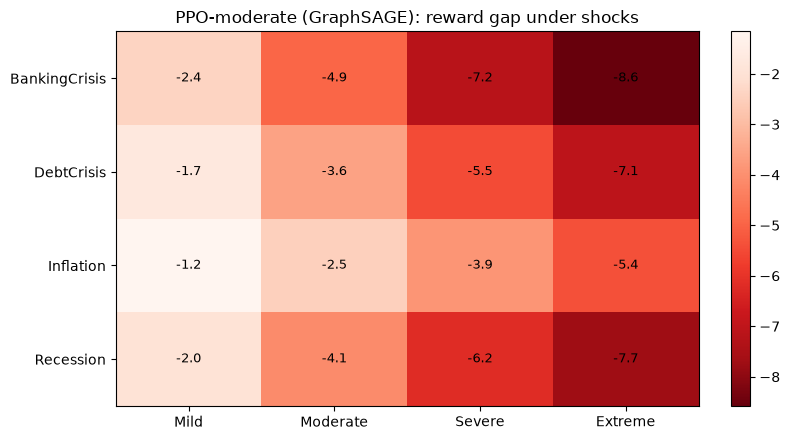


GS vs TGN (mean reward_diff GS-TGN):
  mean diff: 0.008
  GS better count: 13 / 16

Saved payload → D:\univercity\omid_project\economics_project\outputs\phase10\data\phase10_payload.pkl

Cell 4 completed successfully.
PHASE 10 COMPLETED.


In [6]:
# Phase 10 – Cell 4: Shock env wrapper + finalize

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
P9 = PROJECT / "outputs" / "phase9"
OUT_DATA = PROJECT / "outputs" / "phase10" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase10" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase10" / "figures"

print("=" * 60)
print("Phase 10 – Cell 4: Shock env wrapper + finalize")
print("=" * 60)

wrapper_src = textwrap.dedent('''
import numpy as np
from economics_env import EconomicsNetworkEnv

SEVERITY = {"Mild": 0.25, "Moderate": 0.50, "Severe": 0.75, "Extreme": 1.00}
SHOCK_TYPES = {
    "Recession":     {"sr_impact": -0.25, "feature_shift": -0.15},
    "Inflation":     {"sr_impact": -0.15, "feature_shift":  0.10},
    "BankingCrisis": {"sr_impact": -0.30, "feature_shift": -0.20},
    "DebtCrisis":    {"sr_impact": -0.22, "feature_shift": -0.12},
}

class ShockEconomicsEnv(EconomicsNetworkEnv):
    """Economics env with optional shock injected after reset."""
    def __init__(self, *args, shock_type=None, severity=None, shock_every_reset=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.shock_type = shock_type
        self.severity = severity
        self.shock_every_reset = shock_every_reset
        self.last_shock_info = None

    def _apply_shock(self):
        if self.shock_type is None or self.severity is None:
            self.last_shock_info = None
            return
        sev = SEVERITY[self.severity]
        sdef = SHOCK_TYPES[self.shock_type]
        delta_sr = sdef["sr_impact"] * sev + self.rng.normal(0, 0.01 * sev)
        self.current_sr = np.clip(self.current_sr + delta_sr, 0.0, 1.5)
        delta_f = sdef["feature_shift"] * sev
        self.current_features = self.current_features + delta_f + self.rng.normal(
            0, 0.01 * sev, size=self.current_features.shape
        )
        self.last_shock_info = {
            "shock_type": self.shock_type,
            "severity": self.severity,
            "delta_sr": float(delta_sr),
        }

    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        if self.shock_every_reset:
            self._apply_shock()
            obs = self._get_obs()
        return obs, info
''')

wrap_path = OUT_DATA / "shock_env.py"
wrap_path.write_text(wrapper_src, encoding="utf-8")
print(f"Saved wrapper → {wrap_path}")

# GraphSAGE moderate impact heatmap
impact = pd.read_csv(OUT_TAB / "ppo_moderate_shock_impact.csv")
# impact_shock = impact[impact["shock_type"] != "None"].copy()
impact_shock = impact[impact["shock_type"].notna() & (impact["shock_type"] != "None")].copy()
piv = impact_shock.pivot(index="shock_type", columns="severity", values="reward_gap")
col_order = [c for c in ["Mild", "Moderate", "Severe", "Extreme"] if c in piv.columns]
piv = piv[col_order]
piv.to_csv(OUT_TAB / "reward_gap_heatmap_gs.csv")
print("\nGraphSAGE PPO-moderate reward gap:")
print(piv.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(piv.values, aspect="auto", cmap="Reds_r")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f"{piv.values[i, j]:.1f}", ha="center", va="center", fontsize=9)
ax.set_title("PPO-moderate (GraphSAGE): reward gap under shocks")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
fig.savefig(OUT_FIG / "shock_reward_gap_heatmap_gs.png", dpi=150)
plt.show()

# If GS vs TGN comparison exists, short summary
cmp_path = OUT_TAB / "ppo_gs_vs_tgn_under_shocks.csv"
if cmp_path.exists():
    cmp = pd.read_csv(cmp_path)
    print("\nGS vs TGN (mean reward_diff GS-TGN):")
    print(f"  mean diff: {cmp['reward_diff_gs_minus_tgn'].mean():.3f}")
    print(f"  GS better count: {(cmp['reward_diff_gs_minus_tgn'] > 0).sum()} / {len(cmp)}")

payload = {
    "shock_env_module": str(wrap_path),
    "base_env_module": str(P8 / "economics_env.py"),
    "phase9_winner_gs": {
        "algorithm": "PPO", "level": "moderate", "embedding": "GraphSAGE",
        "model_path": str(P9 / "models" / "PPO_moderate_gs.zip"),
    },
    "phase9_tgn_models": {
        "normal": str(PROJECT / "outputs" / "phase9_tgn" / "models" / "PPO_normal.zip"),
        "moderate": str(PROJECT / "outputs" / "phase9_tgn" / "models" / "PPO_moderate.zip"),
        "strict": str(PROJECT / "outputs" / "phase9_tgn" / "models" / "PPO_strict.zip"),
    },
    "shock_types": ["Recession", "Inflation", "BankingCrisis", "DebtCrisis"],
    "severities": ["Mild", "Moderate", "Severe", "Extreme"],
    "eval_gs": str(OUT_TAB / "ppo_moderate_under_shocks.csv"),
    "eval_tgn": str(OUT_TAB / "ppo_tgn_under_shocks.csv"),
    "comparison_gs_tgn": str(cmp_path) if cmp_path.exists() else None,
}
with open(OUT_DATA / "phase10_payload.pkl", "wb") as f:
    pickle.dump(payload, f)

print(f"\nSaved payload → {OUT_DATA / 'phase10_payload.pkl'}")
print("\nCell 4 completed successfully.")
print("PHASE 10 COMPLETED.")

In [7]:
# Phase 10 – Upgrade Cell 5: Strong shocks + eval GS & TGN PPO

from pathlib import Path
import sys
import textwrap
import numpy as np
import pandas as pd
import pickle
from stable_baselines3 import PPO

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8 = PROJECT / "outputs" / "phase8" / "data"
P9 = PROJECT / "outputs" / "phase9"
P9_TGN = PROJECT / "outputs" / "phase9_tgn" / "models"
OUT_DATA = PROJECT / "outputs" / "phase10" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase10" / "tables"

if str(P8) not in sys.path:
    sys.path.insert(0, str(P8))
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 10 – Upgrade: Strong shock series")
print("=" * 60)

# ---- Two series ----
SEVERITY = {"Mild": 0.25, "Moderate": 0.50, "Severe": 0.75, "Extreme": 1.00}

SHOCK_STANDARD = {
    "Recession":     {"sr_impact": -0.25, "feature_shift": -0.15, "persist": 0.0},
    "Inflation":     {"sr_impact": -0.15, "feature_shift":  0.10, "persist": 0.0},
    "BankingCrisis": {"sr_impact": -0.30, "feature_shift": -0.20, "persist": 0.0},
    "DebtCrisis":    {"sr_impact": -0.22, "feature_shift": -0.12, "persist": 0.0},
}

# Stronger base impact + persistence each step
SHOCK_STRONG = {
    "Recession":     {"sr_impact": -0.40, "feature_shift": -0.25, "persist": 0.08},
    "Inflation":     {"sr_impact": -0.28, "feature_shift":  0.18, "persist": 0.06},
    "BankingCrisis": {"sr_impact": -0.50, "feature_shift": -0.35, "persist": 0.10},
    "DebtCrisis":    {"sr_impact": -0.38, "feature_shift": -0.22, "persist": 0.07},
}

SERIES = {"standard": SHOCK_STANDARD, "strong": SHOCK_STRONG}

base = np.load(P8 / "base_features.npy")
emb_gs = np.load(P8 / "emb_GraphSAGE.npy")
emb_tgn_path = P8 / "emb_TGN.npy"
if not emb_tgn_path.exists():
    emb_tgn_path = PROJECT / "outputs" / "phase7" / "data" / "emb_TGN_stable.npy"
emb_tgn = np.load(emb_tgn_path)
sr = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

def apply_shock_once(env, shock_type, severity, series_name, rng):
    sdef = SERIES[series_name][shock_type]
    sev = SEVERITY[severity]
    delta_sr = sdef["sr_impact"] * sev + rng.normal(0, 0.015 * sev)
    env.current_sr = np.clip(env.current_sr + delta_sr, 0.0, 1.5)
    delta_f = sdef["feature_shift"] * sev
    env.current_features = env.current_features + delta_f + rng.normal(
        0, 0.015 * sev, size=env.current_features.shape
    )
    env._shock_persist = sdef["persist"] * sev  # used in strong step dynamics
    return float(delta_sr)

def persist_shock(env, rng):
    """Extra per-step pressure for strong series."""
    p = getattr(env, "_shock_persist", 0.0)
    if p <= 0:
        return
    env.current_sr = np.clip(env.current_sr - abs(p) * 0.15 + rng.normal(0, 0.005), 0.0, 1.5)
    env.current_features = env.current_features - abs(p) * 0.05

def run_eval(model, emb, level, series_name, shock_type=None, severity=None, n_ep=12, seed=0):
    rewards, sr_imps = [], []
    for ep in range(n_ep):
        env = EconomicsNetworkEnv(base, emb, sr, panel, nodes, level=level, seed=seed + ep)
        obs, _ = env.reset(seed=seed + ep)
        rng = np.random.default_rng(seed + 2000 + ep)
        env._shock_persist = 0.0
        if shock_type is not None:
            apply_shock_once(env, shock_type, severity, series_name, rng)
            obs = env._get_obs()
        done, tot, info = False, 0.0, {}
        while not done:
            if series_name == "strong" and shock_type is not None:
                persist_shock(env, rng)
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            tot += r
            done = term or trunc
        rewards.append(tot)
        sr_imps.append(info.get("sr_improve", np.nan))
    return float(np.mean(rewards)), float(np.std(rewards)), float(np.nanmean(sr_imps))

# Models
models = {
    ("GraphSAGE", "moderate"): (P9 / "models" / "PPO_moderate_gs.zip", emb_gs, "moderate"),
    ("TGN", "moderate"): (P9_TGN / "PPO_moderate.zip", emb_tgn, "moderate"),
    ("TGN", "normal"): (P9_TGN / "PPO_normal.zip", emb_tgn, "normal"),
    ("TGN", "strict"): (P9_TGN / "PPO_strict.zip", emb_tgn, "strict"),
}

rows = []
for (emb_name, pol_level), (path, emb, level) in models.items():
    if not path.exists():
        print(f"Missing model: {path}")
        continue
    model = PPO.load(str(path))
    print(f"\n=== {emb_name} PPO | policy_level={pol_level} ===")
    for series_name in ["standard", "strong"]:
        # baseline (no shock) once per series label
        mr, sd, ms = run_eval(model, emb, level, series_name, None, None)
        rows.append({
            "embedding": emb_name, "policy_level": pol_level, "series": series_name,
            "shock_type": "None", "severity": "None",
            "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms,
        })
        print(f"  [{series_name:8s}] Baseline | R={mr:.3f} | dSR={ms:.3f}")
        for st in SHOCK_STRONG:
            for sev in SEVERITY:
                mr, sd, ms = run_eval(model, emb, level, series_name, st, sev)
                rows.append({
                    "embedding": emb_name, "policy_level": pol_level, "series": series_name,
                    "shock_type": st, "severity": sev,
                    "mean_reward": mr, "std_reward": sd, "mean_sr_improve": ms,
                })
                print(f"  [{series_name:8s}] {st:15s} | {sev:8s} | R={mr:.3f} | dSR={ms:.3f}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "ppo_standard_vs_strong_all.csv", index=False)

# Focus comparison: moderate policies GS vs TGN under strong
sub = df[(df.policy_level == "moderate") & (df.series == "strong") & (df.shock_type != "None")]
piv = sub.pivot_table(index=["shock_type", "severity"], columns="embedding", values="mean_reward")
if "GraphSAGE" in piv.columns and "TGN" in piv.columns:
    piv["GS_minus_TGN"] = piv["GraphSAGE"] - piv["TGN"]
piv.to_csv(OUT_TAB / "strong_shock_gs_vs_tgn_moderate.csv")
print("\n--- Strong series | moderate policies | reward ---")
print(piv.round(2).to_string())

# Update shock_env.py with series support
wrap = textwrap.dedent('''
import numpy as np
from economics_env import EconomicsNetworkEnv

SEVERITY = {"Mild": 0.25, "Moderate": 0.50, "Severe": 0.75, "Extreme": 1.00}
SHOCK_SERIES = {
  "standard": {
    "Recession":     {"sr_impact": -0.25, "feature_shift": -0.15, "persist": 0.0},
    "Inflation":     {"sr_impact": -0.15, "feature_shift":  0.10, "persist": 0.0},
    "BankingCrisis": {"sr_impact": -0.30, "feature_shift": -0.20, "persist": 0.0},
    "DebtCrisis":    {"sr_impact": -0.22, "feature_shift": -0.12, "persist": 0.0},
  },
  "strong": {
    "Recession":     {"sr_impact": -0.40, "feature_shift": -0.25, "persist": 0.08},
    "Inflation":     {"sr_impact": -0.28, "feature_shift":  0.18, "persist": 0.06},
    "BankingCrisis": {"sr_impact": -0.50, "feature_shift": -0.35, "persist": 0.10},
    "DebtCrisis":    {"sr_impact": -0.38, "feature_shift": -0.22, "persist": 0.07},
  },
}

class ShockEconomicsEnv(EconomicsNetworkEnv):
    def __init__(self, *args, shock_type=None, severity=None, shock_series="standard",
                 shock_every_reset=True, **kwargs):
        super().__init__(*args, **kwargs)
        self.shock_type = shock_type
        self.severity = severity
        self.shock_series = shock_series
        self.shock_every_reset = shock_every_reset
        self.last_shock_info = None
        self._shock_persist = 0.0

    def _apply_shock(self):
        if self.shock_type is None or self.severity is None:
            self.last_shock_info = None
            self._shock_persist = 0.0
            return
        sdef = SHOCK_SERIES[self.shock_series][self.shock_type]
        sev = SEVERITY[self.severity]
        delta_sr = sdef["sr_impact"] * sev + self.rng.normal(0, 0.015 * sev)
        self.current_sr = np.clip(self.current_sr + delta_sr, 0.0, 1.5)
        delta_f = sdef["feature_shift"] * sev
        self.current_features = self.current_features + delta_f + self.rng.normal(
            0, 0.015 * sev, size=self.current_features.shape)
        self._shock_persist = sdef["persist"] * sev
        self.last_shock_info = {"shock_type": self.shock_type, "severity": self.severity,
                               "series": self.shock_series, "delta_sr": float(delta_sr)}

    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        if self.shock_every_reset:
            self._apply_shock()
            obs = self._get_obs()
        return obs, info

    def step(self, action):
        if self._shock_persist > 0:
            self.current_sr = np.clip(
                self.current_sr - abs(self._shock_persist) * 0.15 + self.rng.normal(0, 0.005),
                0.0, 1.5)
            self.current_features = self.current_features - abs(self._shock_persist) * 0.05
        return super().step(action)
''')
(OUT_DATA / "shock_env.py").write_text(wrap, encoding="utf-8")
print(f"\nUpdated → {OUT_DATA / 'shock_env.py'} (standard + strong)")

with open(OUT_DATA / "shock_engine_spec.pkl", "wb") as f:
    pickle.dump({"severity": SEVERITY, "series": SERIES}, f)

print("\nCell 5 (upgrade) completed successfully.")

Phase 10 – Upgrade: Strong shock series

=== GraphSAGE PPO | policy_level=moderate ===
  [standard] Baseline | R=33.941 | dSR=1.161
  [standard] Recession       | Mild     | R=31.949 | dSR=1.161
  [standard] Recession       | Moderate | R=29.874 | dSR=1.161
  [standard] Recession       | Severe   | R=27.810 | dSR=1.161
  [standard] Recession       | Extreme  | R=26.236 | dSR=1.161
  [standard] Inflation       | Mild     | R=32.755 | dSR=1.160
  [standard] Inflation       | Moderate | R=31.494 | dSR=1.160
  [standard] Inflation       | Severe   | R=30.138 | dSR=1.160
  [standard] Inflation       | Extreme  | R=28.688 | dSR=1.158
  [standard] BankingCrisis   | Mild     | R=31.534 | dSR=1.161
  [standard] BankingCrisis   | Moderate | R=29.021 | dSR=1.161
  [standard] BankingCrisis   | Severe   | R=26.775 | dSR=1.161
  [standard] BankingCrisis   | Extreme  | R=25.357 | dSR=1.162
  [standard] DebtCrisis      | Mild     | R=32.197 | dSR=1.161
  [standard] DebtCrisis      | Moderate | R=30.38